In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from collections import Counter
from nltk.corpus import stopwords

In [4]:
df = pd.read_csv('amazon.csv')

In [16]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [5]:
cols = ['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']

In [6]:
for col in cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r'[^\d.]', '', regex=True)
        .replace('', pd.NA)          # пустые строки -> NaN
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [7]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(0)
    else:
        df[col] = df[col].fillna('Unknown')

In [9]:
main_category = df.category.str.split('|').str[0]

In [10]:
df.insert(2, 'main_category', main_category)

In [11]:
df[['main_category','rating_count']].sort_values(by='rating_count', ascending=False)

,main_category,rating_count
12,Electronics,426973.0
65,Electronics,426973.0
47,Electronics,426973.0
684,Electronics,426972.0
400,Electronics,363713.0
...,...,...
1344,Home&Kitchen,4.0
1309,Home&Kitchen,2.0
1459,Home&Kitchen,2.0
324,Computers&Accessories,0.0


In [12]:
df.discount_percentage.corr(df.rating)

-0.13255588435937218

<AxesSubplot:xlabel='discount_percentage', ylabel='rating'>

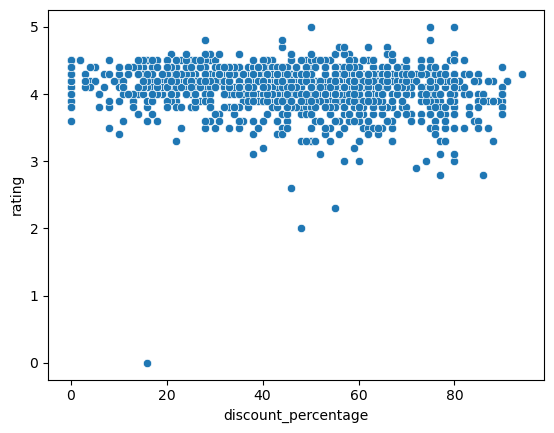

In [13]:
sns.scatterplot(data=df, x='discount_percentage', y='rating')

In [ ]:

# 1. Импортируем библиотеку NLTK и загружаем список стоп-слов
import nltk
nltk.download('stopwords') # Эту строку нужно запустить только один раз
from nltk.corpus import stopwords

# Получаем английские стоп-слова (в датасете Amazon отзывы на английском)
stop_words = set(stopwords.words('english'))

# Добавим туда пару слов, которые часто встречаются, но не несут смысла
stop_words.update(['good', 'product', 'phone', 'cable', 'amazon', 'one'])

# 2. Берем только отзывы с рейтингом ниже 3.5 (предварительно убедись, что rating переведен во float)
bad_reviews = df[df['rating'] < 3.5]['review_content'].dropna()

# 3. Склеиваем все отзывы в один гигантский текст и переводим в нижний регистр
all_text = " ".join(bad_reviews).lower()

# 4. Очищаем от знаков препинания (оставляем только буквы с помощью регулярного выражения)
words = re.findall(r'\b[a-z]+\b', all_text)

# 5. МАГИЯ: удаляем стоп-слова! (оставляем слово, только если его нет в списке stop_words)
meaningful_words = [word for word in words if word not in stop_words]

# 6. Считаем самые популярные слова
word_counts = Counter(meaningful_words)

# Выводим топ-15 самых частых слов
print(word_counts.most_common(15))

In [16]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SUSIK\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
stop_words = set(stopwords.words('english'))

In [18]:
stop_words.update(['good', 'product', 'phone', 'cable', 'amazon', 'one', 'use', 'buy', 'also', 'easy', 'time', 'well', 'ok', 'money'])

In [19]:
bad_reviews = df[df['rating'] < 3.5]['review_content'].dropna()

In [20]:
all_text = " ".join(bad_reviews).lower()

In [21]:
words = re.findall(r'\b[a-z]+\b', all_text)

In [22]:
meaningful_words = [word for word in words if word not in stop_words]

In [23]:
word_counts = Counter(meaningful_words)

In [24]:
print(word_counts.most_common(15))

[('quality', 53), ('remote', 41), ('working', 40), ('price', 24), ('bluetooth', 24), ('work', 18), ('tv', 17), ('best', 17), ('usb', 17), ('works', 17), ('charging', 16), ('using', 16), ('first', 16), ('without', 15), ('battery', 15)]


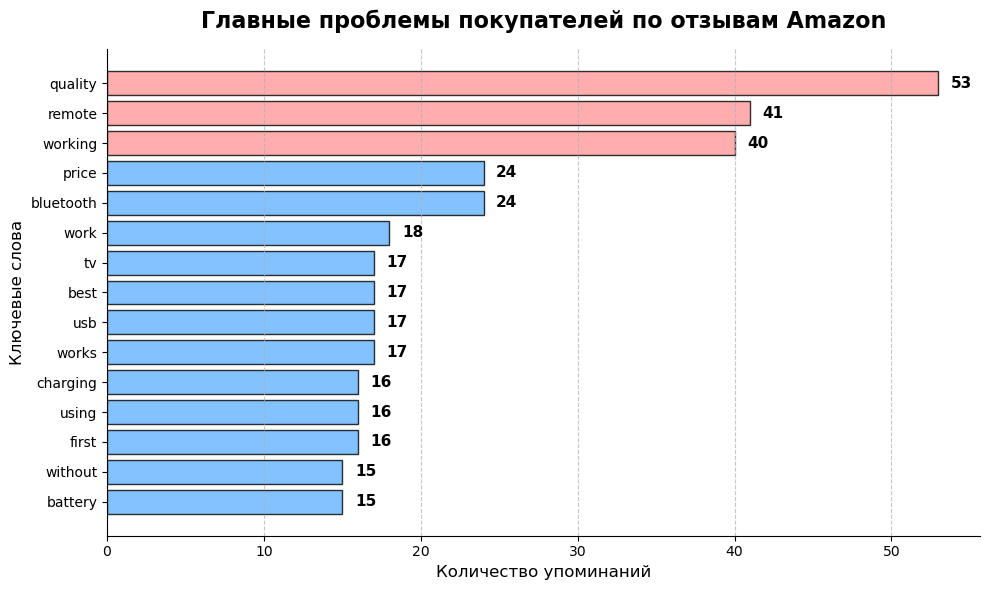

In [28]:
data = [('quality', 53), ('remote', 41), ('working', 40), ('price', 24), ('bluetooth', 24), ('work', 18), ('tv', 17), ('best', 17), ('usb', 17), ('works', 17), ('charging', 16), ('using', 16), ('first', 16), ('without', 15), ('battery', 15)]

words = [item[0] for item in data][::-1]
counts = [item[1] for item in data][::-1]

plt.figure(figsize=(10, 6))

colors = ['#ff9999' if i >= len(words)-3 else '#66b3ff' for i in range(len(words))]
bars = plt.barh(words, counts, color=colors, edgecolor='black', alpha=0.8)

plt.title('Главные проблемы покупателей по отзывам Amazon', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Количество упоминаний', fontsize=12)
plt.ylabel('Ключевые слова', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

for bar in bars:
    plt.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2, 
             str(int(bar.get_width())), 
             va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()